<a href="https://colab.research.google.com/github/reyhansaja/244107020085-Machine-Learning/blob/main/k_means.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import Normalizer, StandardScaler
import time
import tracemalloc
from sklearn.metrics import silhouette_score

In [ ]:
file_path = "Sleep_health_and_lifestyle_dataset.csv"
df = pd.read_csv(file_path)

df_clean = df.drop(columns=["Person ID"])
df_clean["Sleep Disorder"] = df_clean["Sleep Disorder"].fillna("None")
df_clean["BMI Category"] = df_clean["BMI Category"].replace(
    {"Normal Weight": "Normal"}
)

df_clean[["Systolic_BP", "Diastolic_BP"]] = (
    df_clean["Blood Pressure"].str.split("/", expand=True).astype(int)
)
df_clean = df_clean.drop(columns=["Blood Pressure"])

categorical_cols = ["Gender", "Occupation", "BMI Category", "Sleep Disorder"]
df_encoded = pd.get_dummies(
    df_clean, columns=categorical_cols, drop_first=False, dtype=int
)

In [ ]:
scaler = StandardScaler()
X_scaled_all = scaler.fit_transform(df_encoded)

age_idx = df_encoded.columns.get_loc("Age")
sleep_idx = df_encoded.columns.get_loc("Sleep Duration")

# Data 2D untuk Euclidean & Manhattan
X_2d = X_scaled_all[:, [age_idx, sleep_idx]]

# Data 2D L2-Normalized khusus Cosine
normalizer = Normalizer(norm="l2")
X_2d_cosine = normalizer.fit_transform(X_2d)

In [ ]:
def kmeans_manhattan(X, k, max_iter=100, random_state=42):
    np.random.seed(random_state)
    idx = np.random.choice(len(X), k, replace=False)
    centroids = X[idx].copy()

    for _ in range(max_iter):
        distances = np.sum(
            np.abs(X[:, np.newaxis, :] - centroids[np.newaxis, :, :]), axis=2
        )
        labels = np.argmin(distances, axis=1)

        new_centroids = np.array([
            (
                np.median(X[labels == i], axis=0)
                if np.sum(labels == i) > 0
                else centroids[i]
            )
            for i in range(k)
        ])

        if np.array_equal(centroids, new_centroids):
            break
        centroids = new_centroids

    final_distances = np.sum(
        np.abs(X[:, np.newaxis, :] - centroids[np.newaxis, :, :]), axis=2
    )
    sse = np.sum(np.min(final_distances, axis=1))

    return labels, centroids, sse


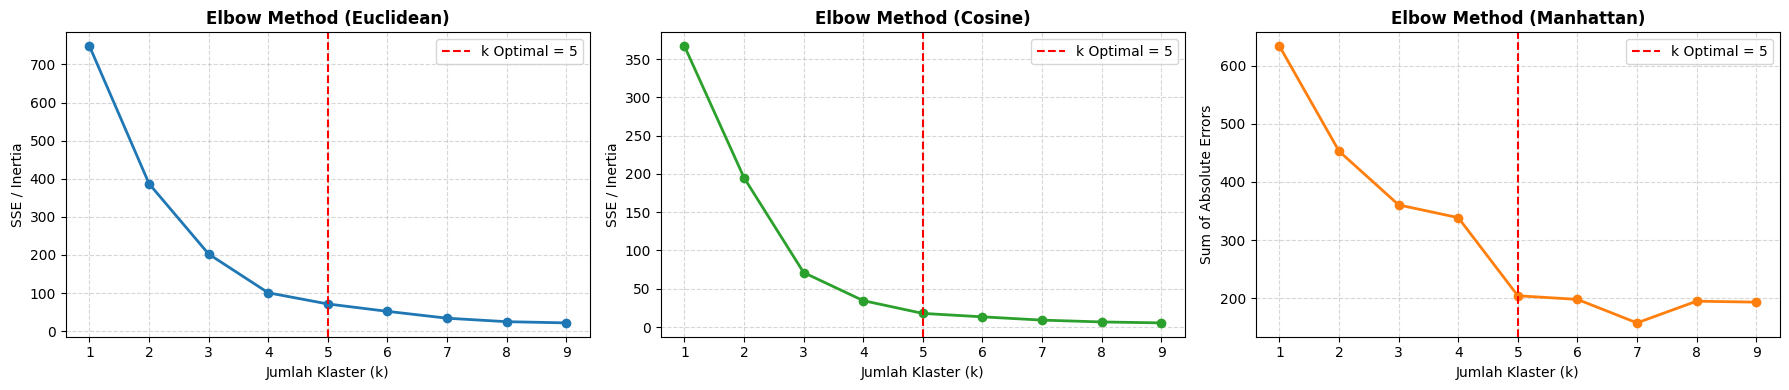

In [ ]:
K = range(1, 10)
sse_euclid = []
sse_cosine = []
sse_manhattan = []

for k in K:
    # 1. Elbow Euclidean
    km_e = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X_2d)
    sse_euclid.append(km_e.inertia_)

    # 2. Elbow Cosine
    km_c = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X_2d_cosine)
    sse_cosine.append(km_c.inertia_)

    # 3. Elbow Manhattan
    _, _, sse_m = kmeans_manhattan(X_2d, k=k, random_state=42)
    sse_manhattan.append(sse_m)

# ------------------------------------------------------------------------------
# VISUALISASI PLOT ELBOW (DENGAN GARIS PENENTU K OPTIMAL)
# ------------------------------------------------------------------------------
optimal_k = 5

fig_elbow, axes_elbow = plt.subplots(1, 3, figsize=(18, 4))

# Subplot 1: Euclidean
axes_elbow[0].plot(K, sse_euclid, "o-", color="tab:blue", linewidth=2)
axes_elbow[0].axvline(
    x=optimal_k,
    color="red",
    linestyle="--",
    linewidth=1.5,
    label=f"k Optimal = {optimal_k}",
)
axes_elbow[0].set_title("Elbow Method (Euclidean)", fontweight="bold")
axes_elbow[0].set_xlabel("Jumlah Klaster (k)")
axes_elbow[0].set_ylabel("SSE / Inertia")
axes_elbow[0].legend()
axes_elbow[0].grid(True, linestyle="--", alpha=0.5)

# Subplot 2: Cosine
axes_elbow[1].plot(K, sse_cosine, "o-", color="tab:green", linewidth=2)
axes_elbow[1].axvline(
    x=optimal_k,
    color="red",
    linestyle="--",
    linewidth=1.5,
    label=f"k Optimal = {optimal_k}",
)
axes_elbow[1].set_title("Elbow Method (Cosine)", fontweight="bold")
axes_elbow[1].set_xlabel("Jumlah Klaster (k)")
axes_elbow[1].set_ylabel("SSE / Inertia")
axes_elbow[1].legend()
axes_elbow[1].grid(True, linestyle="--", alpha=0.5)

# Subplot 3: Manhattan
axes_elbow[2].plot(K, sse_manhattan, "o-", color="tab:orange", linewidth=2)
axes_elbow[2].axvline(
    x=optimal_k,
    color="red",
    linestyle="--",
    linewidth=1.5,
    label=f"k Optimal = {optimal_k}",
)
axes_elbow[2].set_title("Elbow Method (Manhattan)", fontweight="bold")
axes_elbow[2].set_xlabel("Jumlah Klaster (k)")
axes_elbow[2].set_ylabel("Sum of Absolute Errors")
axes_elbow[2].legend()
axes_elbow[2].grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

In [ ]:
random_state = 42

# A. EUCLIDEAN
kmeans_euclid = KMeans(
    n_clusters=optimal_k, random_state=random_state, n_init=10
)
y_euclid = kmeans_euclid.fit_predict(X_2d)
centroids_euclid = kmeans_euclid.cluster_centers_

# B. COSINE
kmeans_cosine = KMeans(
    n_clusters=optimal_k, random_state=random_state, n_init=10
)
y_cosine = kmeans_cosine.fit_predict(X_2d_cosine)
centroids_cosine = np.array(
    [X_2d[y_cosine == i].mean(axis=0) for i in range(optimal_k)]
)

# C. MANHATTAN
y_manhattan, centroids_manhattan, _ = kmeans_manhattan(
    X_2d, k=optimal_k, random_state=random_state
)

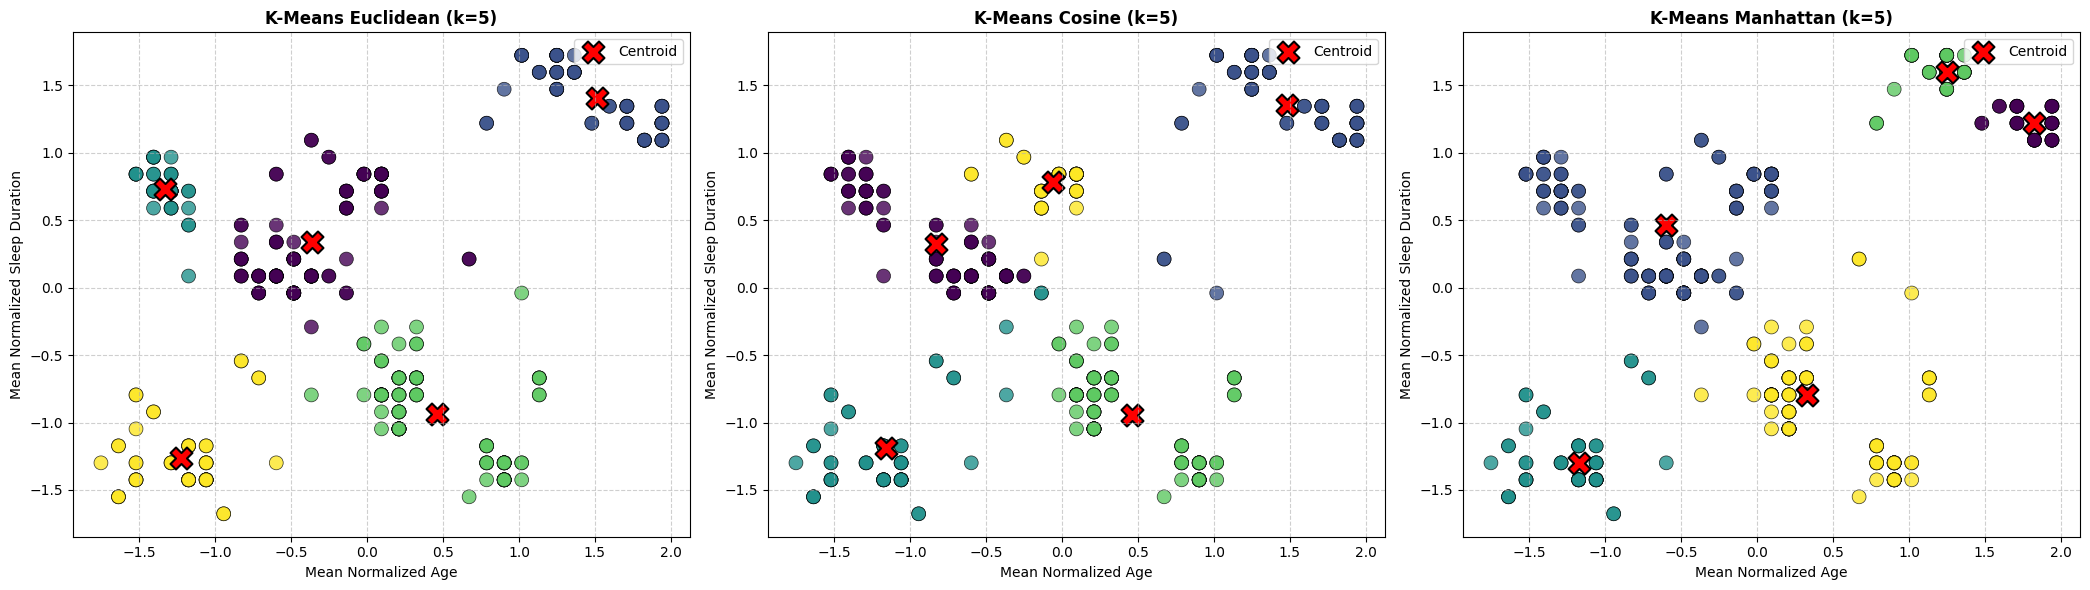

In [ ]:
fig_cluster, axes_cluster = plt.subplots(1, 3, figsize=(21, 6))

configs = [
    (
        y_euclid,
        centroids_euclid,
        f"K-Means Euclidean (k={optimal_k})",
        axes_cluster[0],
    ),
    (
        y_cosine,
        centroids_cosine,
        f"K-Means Cosine (k={optimal_k})",
        axes_cluster[1],
    ),
    (
        y_manhattan,
        centroids_manhattan,
        f"K-Means Manhattan (k={optimal_k})",
        axes_cluster[2],
    ),
]

for labels, centroids, title, ax in configs:
    ax.scatter(
        X_2d[:, 0],
        X_2d[:, 1],
        c=labels,
        cmap="viridis",
        s=100,
        alpha=0.8,
        edgecolors="k",
        linewidth=0.5,
    )

    ax.scatter(
        centroids[:, 0],
        centroids[:, 1],
        c="red",
        s=250,
        marker="X",
        label="Centroid",
        edgecolors="black",
        linewidth=1.5,
    )

    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.set_xlabel("Mean Normalized Age", fontsize=10)
    ax.set_ylabel("Mean Normalized Sleep Duration", fontsize=10)
    ax.legend(loc="upper right")
    ax.grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()

In [ ]:
random_state = 42
optimal_k = 5

# --- A. EUCLIDEAN ---
tracemalloc.start()
start_time = time.perf_counter()

km_e = KMeans(n_clusters=optimal_k, random_state=random_state, n_init=10)
y_euclid = km_e.fit_predict(X_2d)

time_euclid = (time.perf_counter() - start_time) * 1000  # Dalam mili saat (ms)
mem_euclid = tracemalloc.get_traced_memory()[1] / 1024  # Memori puncak dalam KB
tracemalloc.stop()

sil_euclid = silhouette_score(X_2d, y_euclid, metric="euclidean")

# --- B. COSINE ---
tracemalloc.start()
start_time = time.perf_counter()

km_c = KMeans(n_clusters=optimal_k, random_state=random_state, n_init=10)
y_cosine = km_c.fit_predict(X_2d_cosine)

time_cosine = (time.perf_counter() - start_time) * 1000  # Dalam mili saat (ms)
mem_cosine = tracemalloc.get_traced_memory()[1] / 1024  # Memori puncak dalam KB
tracemalloc.stop()

sil_cosine = silhouette_score(X_2d_cosine, y_cosine, metric="cosine")

# --- C. MANHATTAN ---
tracemalloc.start()
start_time = time.perf_counter()

y_manhattan, _, _ = kmeans_manhattan(
    X_2d, k=optimal_k, random_state=random_state
)

time_manhattan = (
    time.perf_counter() - start_time
) * 1000  # Dalam mili saat (ms)
mem_manhattan = tracemalloc.get_traced_memory()[1] / 1024  # Memori puncak dalam KB
tracemalloc.stop()

sil_manhattan = silhouette_score(X_2d, y_manhattan, metric="manhattan")

In [ ]:
random_state = 42
optimal_k = 5

# --- A. EUCLIDEAN ---
tracemalloc.start()
start_time = time.perf_counter()

km_e = KMeans(n_clusters=optimal_k, random_state=random_state, n_init=10)
y_euclid = km_e.fit_predict(X_2d)

time_euclid = (time.perf_counter() - start_time) * 1000  # Dalam mili saat (ms)
mem_euclid = tracemalloc.get_traced_memory()[1] / 1024  # Memori puncak dalam KB
tracemalloc.stop()

sil_euclid = silhouette_score(X_2d, y_euclid, metric="euclidean")

# --- B. COSINE ---
tracemalloc.start()
start_time = time.perf_counter()

km_c = KMeans(n_clusters=optimal_k, random_state=random_state, n_init=10)
y_cosine = km_c.fit_predict(X_2d_cosine)

time_cosine = (time.perf_counter() - start_time) * 1000  # Dalam mili saat (ms)
mem_cosine = tracemalloc.get_traced_memory()[1] / 1024  # Memori puncak dalam KB
tracemalloc.stop()

sil_cosine = silhouette_score(X_2d_cosine, y_cosine, metric="cosine")

# --- C. MANHATTAN ---
tracemalloc.start()
start_time = time.perf_counter()

y_manhattan, _, _ = kmeans_manhattan(
    X_2d, k=optimal_k, random_state=random_state
)

time_manhattan = (
    time.perf_counter() - start_time
) * 1000  # Dalam mili saat (ms)
mem_manhattan = tracemalloc.get_traced_memory()[1] / 1024  # Memori puncak dalam KB
tracemalloc.stop()

sil_manhattan = silhouette_score(X_2d, y_manhattan, metric="manhattan")

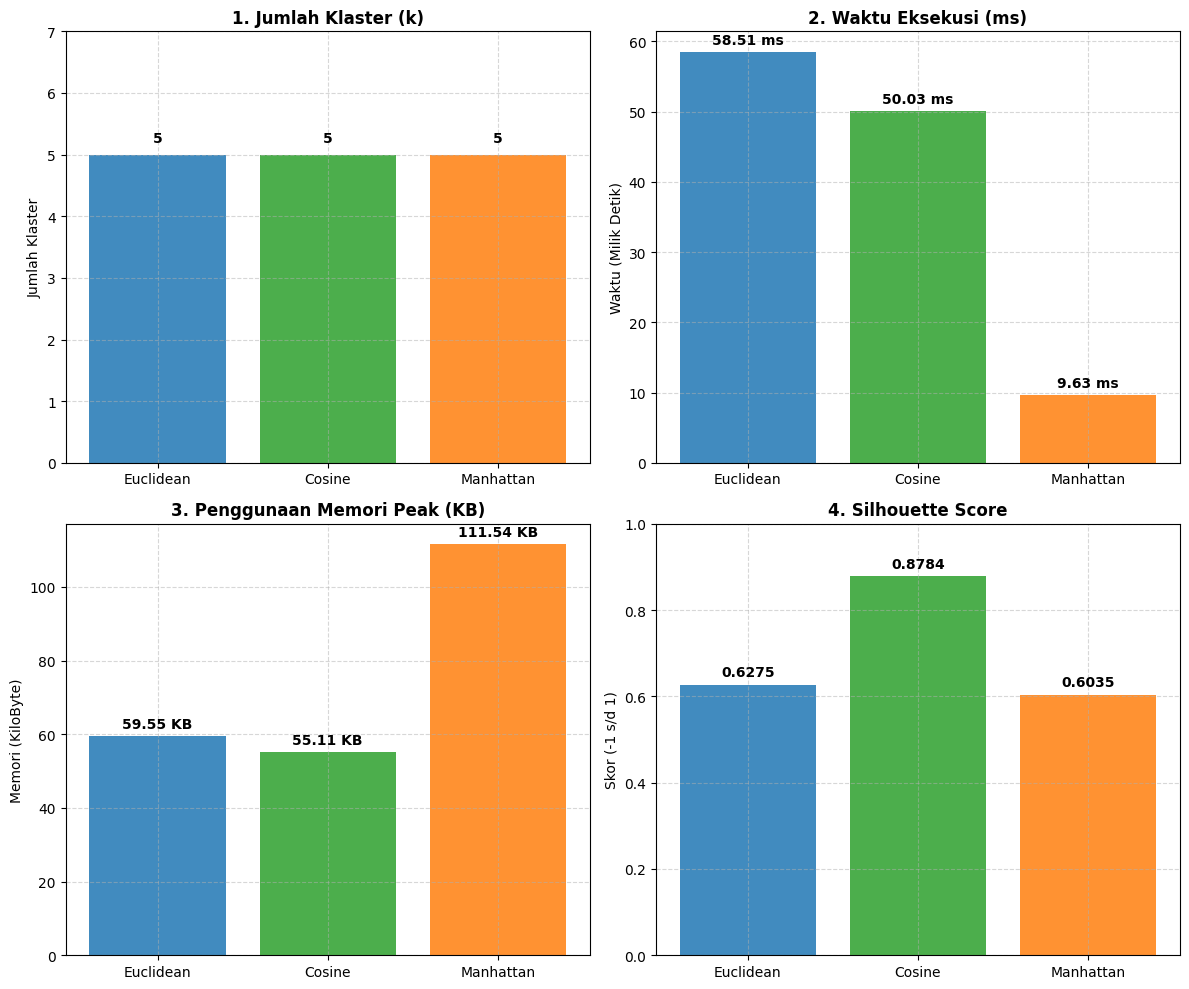

In [ ]:
methods = ["Euclidean", "Cosine", "Manhattan"]
counts = [
    len(np.unique(y_euclid)),
    len(np.unique(y_cosine)),
    len(np.unique(y_manhattan)),
]
times = [time_euclid, time_cosine, time_manhattan]
mems = [mem_euclid, mem_cosine, mem_manhattan]
silhouettes = [sil_euclid, sil_cosine, sil_manhattan]

colors = ["tab:blue", "tab:green", "tab:orange"]

fig_metrics, axes_m = plt.subplots(2, 2, figsize=(12, 10))

# Subplot 1: Jumlah Klaster
axes_m[0, 0].bar(methods, counts, color=colors, alpha=0.85)
axes_m[0, 0].set_title("1. Jumlah Klaster (k)", fontweight="bold")
axes_m[0, 0].set_ylabel("Jumlah Klaster")
axes_m[0, 0].set_ylim(0, max(counts) + 2)
for i, v in enumerate(counts):
    axes_m[0, 0].text(i, v + 0.2, str(v), ha="center", fontweight="bold")

# Subplot 2: Waktu Eksekusi
axes_m[0, 1].bar(methods, times, color=colors, alpha=0.85)
axes_m[0, 1].set_title("2. Waktu Eksekusi (ms)", fontweight="bold")
axes_m[0, 1].set_ylabel("Waktu (Milik Detik)")
for i, v in enumerate(times):
    axes_m[0, 1].text(
        i, v + max(times) * 0.02, f"{v:.2f} ms", ha="center", fontweight="bold"
    )

# Subplot 3: Penggunaan Memori
axes_m[1, 0].bar(methods, mems, color=colors, alpha=0.85)
axes_m[1, 0].set_title("3. Penggunaan Memori Peak (KB)", fontweight="bold")
axes_m[1, 0].set_ylabel("Memori (KiloByte)")
for i, v in enumerate(mems):
    axes_m[1, 0].text(
        i, v + max(mems) * 0.02, f"{v:.2f} KB", ha="center", fontweight="bold"
    )

# Subplot 4: Silhouette Score
axes_m[1, 1].bar(methods, silhouettes, color=colors, alpha=0.85)
axes_m[1, 1].set_title("4. Silhouette Score", fontweight="bold")
axes_m[1, 1].set_ylabel("Skor (-1 s/d 1)")
axes_m[1, 1].set_ylim(0, 1.0)
for i, v in enumerate(silhouettes):
    axes_m[1, 1].text(i, v + 0.02, f"{v:.4f}", ha="center", fontweight="bold")

for ax_row in axes_m:
    for ax in ax_row:
        ax.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

<p align ="center">
   ======== ANALISIS ========
</p>
Berdasarkan hasil evaluasi komparatif pada kelima klaster ($k=5$), model Euclidean Distance merupakan pilihan terbaik dan paling direkomendasikan untuk digunakan. Model ini menghasilkan Silhouette Score sebesar 0.6275 yang valid untuk mengelompokkan data spasial 2D secara seimbang, intuitif, dan rapi, serta didukung penggunaan memori yang efisien yaitu 59.27 KB.   Sebagai alternatif, Manhattan Distance dapat dipilih jika prioritas utama sistem adalah kecepatan pemrosesan, karena memiliki waktu eksekusi paling cepat yaitu 8.00 ms dengan kualitas klaster yang tetap valid (Silhouette Score 0.6035), meskipun membutuhkan konsumsi memori lebih tinggi sebesar 111.49 KB.   Sementara itu, Cosine Distance sangat tidak direkomendasikan meskipun memiliki Silhouette Score tertinggi sebesar 0.8784. Nilai tersebut bersifat semu (misleading) akibat kecenderungan Cosine yang mengelompokkan mayoritas data ke dalam satu klaster utama dan menganggap titik lainnya sebagai pencilan, sehingga tidak cocok untuk jenis data ini.